In [1]:
#replaces old <TimeMeasurement.ipynb>

import naive

InputJets = naive.JetReader("PythiaEventsBatchTest.root",'pdEventTree')

In [2]:
##### POPULATING GHOST JETS #####

# phi bounds are obvious: 0 to 2pi
# ? How do I decide bounds of y?
# For simplicity for now, I'll settle for max, min

ymin = min([jet.y for jet in InputJets])
ymax = max([jet.y for jet in InputJets])

print(f"y_min: {ymin}")
print(f"y_max: {ymax}")

y_min: -8.514232250012876
y_max: 9.136680552668757


In [3]:
import numpy as np
pi = float(np.pi)
pi

3.141592653589793

In [4]:
def TimingMeasurement(inputjets, ClusterFunc, *args, **kwargs):

  """
  Measures how much time it takes to cluster a set of jets.

  returns N, time_result, dt
    with N = number of initial jets clustered (including ghosts),
    time_result = average time elapsed in seconds,
    and dt = standard deviation from five trials

  """

  t_list = []

  for count in range(5):

    print(f"Trial {count} begins...")
    start = time.perf_counter()
    ClusterFunc(*args, **kwargs)
    end = time.perf_counter()

    t_list.append(end-start)
    print(f"Trial {count} complete: reading {end-start} seconds")

  dt = statistics.stdev(t_list)
  time_result = statistics.mean(t_list)



  return len(inputjets), time_result, dt

In [5]:
import uproot
import fastjet

file4 = uproot.open("PythiaEventsBatchTest.root")

tree = file4['pdEventTree']

#read branches into Awkward array, then numpy arrays

E_array = tree['E'].array().to_numpy()
px_array = tree['px'].array().to_numpy()
py_array = tree['py'].array().to_numpy()
pz_array = tree['pz'].array().to_numpy()
eta_array = tree['eta'].array().to_numpy()
phi_array = tree['phi'].array().to_numpy()

InputJets_fj = [fastjet.PseudoJet(px_array[i], py_array[i], pz_array[i], E_array[i]) for i in range(len(E_array))]

In [6]:
len(InputJets) == len(InputJets_fj)

True

In [7]:
print(len(InputJets))
print(len(InputJets_fj))
print(len(E_array))

143
143
143


In [8]:
import time 
import statistics

nlist = [i for i in range(5,11)]

N_data = []
t_data = []
dt_data = []

runcount = len(nlist)

for _n in nlist:

  InputJetsGhosted = naive.GhostJetPopulator(InputJets, ymin, ymax, _n, 0, 2*pi, _n)

  n_result, t_result, dt_result = TimingMeasurement(inputjets=InputJetsGhosted, j_initial=InputJetsGhosted, ClusterFunc=naive.gen_clustering, mode=-1, R_0=0.4)

  N_data.append(n_result)
  t_data.append(t_result)
  dt_data.append(dt_result)

  print(f"{n_result} clustered in {t_result} +/- {dt_result} seconds")

Trial 0 begins...
Trial 0 complete: reading 6.856528456999996 seconds
Trial 1 begins...
Trial 1 complete: reading 6.6275911650000126 seconds
Trial 2 begins...
Trial 2 complete: reading 6.945206573000007 seconds
Trial 3 begins...
Trial 3 complete: reading 6.705377527999985 seconds
Trial 4 begins...
Trial 4 complete: reading 6.7796432100000175 seconds
168 clustered in 6.782869386600003 +/- 0.12440432388833596 seconds
Trial 0 begins...
Trial 0 complete: reading 12.207308666000017 seconds
Trial 1 begins...
Trial 1 complete: reading 12.204485936999987 seconds
Trial 2 begins...
Trial 2 complete: reading 12.11437995 seconds
Trial 3 begins...
Trial 3 complete: reading 12.234637464999992 seconds
Trial 4 begins...
Trial 4 complete: reading 12.161131745000006 seconds
204 clustered in 12.1843887526 +/- 0.04716002860718065 seconds
Trial 0 begins...
Trial 0 complete: reading 23.370280456000017 seconds
Trial 1 begins...
Trial 1 complete: reading 24.05634147699999 seconds
Trial 2 begins...
Trial 2 com

In [9]:
def GhostJetPopulator_fastjet_version(jet_input, y_min, y_max, ny, phi_min, phi_max, nphi, epsil=1e-6, version=1):
  """
  Populates a set of input jets with ghosts jets. In particular, takes jet_input set,
  and adds a series of ny*nphi many ghost jets in a uniform (y,phi) grid.

  Parameters:
      jet_input (list): List of input jets.
      y_min, y_max (float): rapidity (y) bounds of the uniform (y,phi) grid where ghost jets are populated.
      phi_min, phi_max (float): phi-bounds of the uniform (y,phi) grid where ghost jets are populated.
      ny, nphi: number of ghost jets populated along y,phi axis respectively, resulting in N = ny*nphi many ghost jets.

      epsil (float): Energy of ghost jet, by default a soft, massless jet, with E = |p|= epsil.

      version (-1 or 1): alternating between versions of ghost jet indexing.

  Returns:
      list: List of input jets with added ghost jets.

  """

  y_axis = np.linspace(y_min, y_max, ny)
  phi_axis = np.linspace(phi_min, phi_max, nphi)


  y_grid, phi_grid = np.meshgrid(y_axis, phi_axis)

  y_phi_coordinates = np.column_stack((y_grid.ravel(), phi_grid.ravel()))

  # creating soft jets, using E = |p|= epsil,
  # and obtaining p-components through y, phi with
  # pz = E*tanh(y); pT = E**2 - pz**2,
  # px = pT*cos(phi); py = pT*sin(phi)

  pz_values = epsil * np.tanh(y_grid.ravel())
  pT_values = np.sqrt(epsil**2 - pz_values**2)
  px_values = pT_values * np.cos(phi_grid.ravel())
  py_values = pT_values * np.sin(phi_grid.ravel())

  #assigns indices to ghost jets sequentially, as len(jet_input), len(jet_input)+1, len(jet_input)+2, and so on.
  #input particles in jet_input assumed to be indexed as integers, from 0, 1, 2, ..., len(jet_input)-1.

  if version == 1:
    ghost_jets = [fastjet.PseudoJet(px, py, pz, epsil) for i, (px, py, pz) in enumerate(zip(px_values.ravel(), py_values.ravel(), pz_values.ravel()))]
    # for gj in ghost_jets:
    #     print(gj)
  elif version == -1:
    ghost_jets = [fastjet.PseudoJet(px, py, pz, epsil) for i, (px, py, pz) in enumerate(zip(px_values.ravel(), py_values.ravel(), pz_values.ravel()))]
  else:
    raise ValueError("Invalid version value. Must be -1 or 1.")
  #alternate possibility: index as negative numbers [i+len(jet_input)] --> [-(i+1)] (as i starts at 0), so one can more easily distinguish ghost jets by index


  jet_input += ghost_jets

  return jet_input

  jet_input += ghost_jets

  return jet_input

#!!!! key edit: on ghost_jets lines; needed to change "fastjet.PseudoJet(px,py,pz,E)" -> "fastjet.PseudoJet(px,py,pz,epsil)"

In [10]:
antikt_jetdef = fastjet.JetDefinition(fastjet.antikt_algorithm, 0.4)

In [11]:
def do_fj_clustering(inputjetset, jetdef):
    _cluster = fastjet.ClusterSequence(inputjetset, jetdef)

In [12]:
N_fj_data = []
t_fj_data = []
dt_fj_data = []

runcount = len(nlist)

#just comparing antikt:

for _n in nlist:

  InputJetsGhosted_fj = GhostJetPopulator_fastjet_version(InputJets_fj, ymin, ymax, _n, 0, 2*pi, _n)
    
  n_result, t_result, dt_result = TimingMeasurement(InputJetsGhosted_fj, do_fj_clustering, inputjetset=InputJetsGhosted_fj, jetdef=antikt_jetdef)

  N_fj_data.append(n_result)
  t_fj_data.append(t_result)
  dt_fj_data.append(dt_result)

  print(f"{n_result} clustered in {t_result} +/- {dt_result} seconds")

Trial 0 begins...
Trial 0 complete: reading 0.0012281020003683807 seconds
Trial 1 begins...
Trial 1 complete: reading 0.00023902199973235838 seconds
Trial 2 begins...
Trial 2 complete: reading 0.00017985600015890668 seconds
Trial 3 begins...
Trial 3 complete: reading 0.00021110200032126158 seconds
Trial 4 begins...
Trial 4 complete: reading 0.0001731659999677504 seconds
168 clustered in 0.00040624960010973157 +/- 0.0004601823145764946 seconds
Trial 0 begins...
Trial 0 complete: reading 0.0004033249997519306 seconds
Trial 1 begins...
Trial 1 complete: reading 0.00022866600011184346 seconds
Trial 2 begins...
Trial 2 complete: reading 0.00020803899997190456 seconds
Trial 3 begins...
Trial 3 complete: reading 0.0001985709996006335 seconds
Trial 4 begins...
Trial 4 complete: reading 0.00019755699986490072 seconds
204 clustered in 0.0002472315998602426 +/- 8.814946223899244e-05 seconds
Trial 0 begins...
Trial 0 complete: reading 0.0003250120003031043 seconds
Trial 1 begins...
Trial 1 complet

In [13]:
len(InputJets) == len(InputJets_fj)

True

In [14]:
import pandas as pd

tvNdf = pd.DataFrame({
    "t": t_data,
    "dt": dt_data,
    "N": N_data
})

tvNdf.to_csv('timing_data_naive.csv')

tvNdf_fj = pd.DataFrame({
    "t": t_fj_data,
    "dt": dt_fj_data,
    "N": N_fj_data
})

tvNdf.to_csv('timing_data_fj.csv')

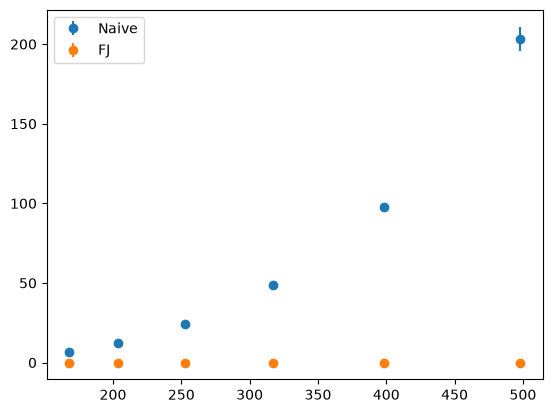

In [17]:
import matplotlib.pyplot as plt

plt.errorbar(N_data,t_data,yerr=dt_data,fmt="o",label="Naive")
plt.errorbar(N_fj_data,t_fj_data,yerr=dt_fj_data,fmt="o",label="FJ")
plt.legend()
plt.show()

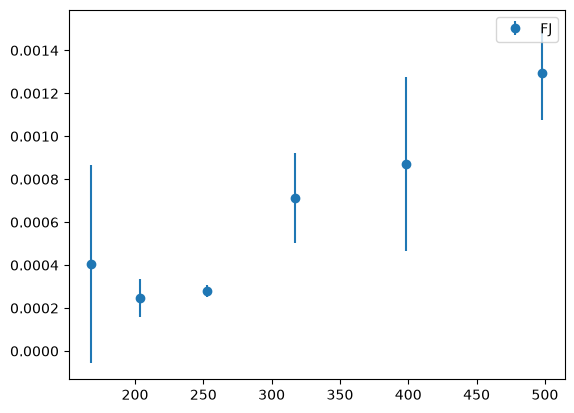

In [19]:
#plot fastjet data separately, to avoid flattenning graph and making its patterns more visible upon inspection

plt.errorbar(N_fj_data,t_fj_data,yerr=dt_fj_data,fmt="o",label="FJ")
plt.legend()
plt.show()

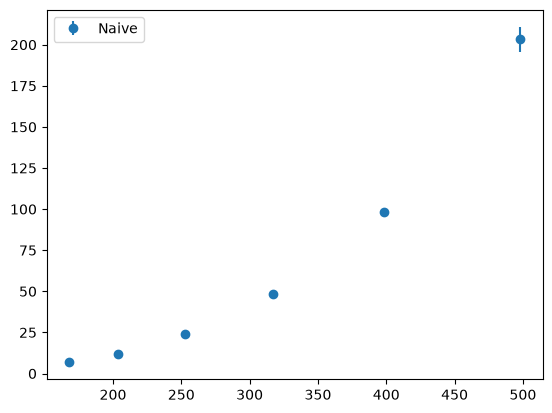

In [20]:
plt.errorbar(N_data,t_data,yerr=dt_data,fmt="o",label="Naive")
plt.legend()
plt.show()